# Gravity Assist and Planetary Flyby Mechanics: Hyperbolic Scattering, B-Plane Targeting, and Energy Pumping

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mukid1805/NewtonianPropagator/blob/main/notebooks/02_gravity_assist_and_flyby_mechanics.ipynb)
[![nbviewer](https://img.shields.io/badge/Render-nbviewer-orange?style=flat&logo=jupyter)](https://nbviewer.org/github/mukid1805/NewtonianPropagator/blob/main/notebooks/02_gravity_assist_and_flyby_mechanics.ipynb)
[![GitHub Source](https://img.shields.io/badge/GitHub-Repository-181717?style=flat&logo=github)](https://github.com/mukid1805/NewtonianPropagator)
[![Python 3.10+](https://img.shields.io/badge/Python-3.10%2B-blue?style=flat&logo=python&logoColor=white)](https://www.python.org/)

---

### Abstract & Scope
This investigation examines the kinematics and orbital mechanics of unpowered gravity-assist encounters (planetary flybys) within the patched-conics framework:

1. **Hyperbolic Scattering Kinematics:** Formulation of the turning angle ($\delta$), periapsis distance ($r_p$), asymptotic excess velocity vectors ($\mathbf{v}_\infty^-, \mathbf{v}_\infty^+$), and heliocentric orbital energy modulation ($\Delta \mathcal{E}$).
2. **Trailing vs. Leading Flyby Asymmetry:** Mathematical distinction between velocity-vector rotation that adds heliocentric orbital energy (energy pumping) versus geometries that extract energy (energy dumping).
3. **B-Plane (Öpik) Geometry:** Formulation of the encounter reference frame ($\mathbf{S}, \mathbf{T}, \mathbf{R}$) and targeting parameterisation via the impact parameter vector $\mathbf{B}$.
4. **Resonant & Chained Encounters:** Tisserand criterion analysis ($T_p$) for outer-planet mission architectures (e.g., Jupiter-assisted transfers to Saturn).
5. **Numerical Cross-Validation:** Propagation across a planetary Sphere of Influence (SOI) using the embedded Dormand-Prince adaptive integrator (`rk45_adaptive`) to verify asymptotic patched-conic analytics against numerical ephemerides.

As you move through the notebook, the examples and case studies shift to best demonstrate each specific concept.

#### Engineering Fidelity & Model Assumptions
The analytical results generated in this study correspond to **Phase-A preliminary mission design and architecture trade formulation**. Key dynamical assumptions include:
* **Gravitational Field:** Central-body heliocentric point-mass dynamics ($\mu_\odot$). Third-body gravitational perturbations (e.g., Jupiter, the Earth-Moon barycentre), solar radiation pressure (SRP), and general relativistic corrections are excluded from this preliminary baseline.
* **Patched-Conics Formulation:** Zero-radius sphere-of-influence (SOI) boundaries are assumed for departure and arrival targeting. The characteristic energy $C_3$ and arrival hyperbolic excess speed $v_{\infty,\text{arr}}$ provide boundary conditions for planetary escape and capture hyperbolae.
* **Ephemeris Resolution:** Planetary states are resolved via analytical mean orbital element expansions accurate to within first-order secular variations. For operational deep-space navigation (Phase C/D), these analytical vectors are routinely substituted with numerical ephemerides (e.g., NASA JPL DE440 SPICE kernels) augmented with trajectory correction manoeuvre ($\Delta v_{\text{TCM}}$) allocations.

In [69]:
import datetime
import numpy as np
import matplotlib.pyplot as plt

import core
from core.constants import AU
from core.time import SECS_PER_DAY
from core.ephemeris import MU_SUN, get_planet_state
from core.integrators import rk45_adaptive

print(f"Initialised NewtonianPropagator v{getattr(core, '__version__', '1.0.0')}")

# Gravitational parameters (km^3/s^2) and physical radii (km)
MU_VENUS = 324859.0
R_VENUS = 6051.8

MU_EARTH = 398600.4418
R_EARTH = 6378.137

MU_JUPITER = 126686534.0
R_JUPITER = 71492.0

print(f"Loaded gravitational parameters: Venus, Earth, Jupiter.")

Initialised NewtonianPropagator v1.0.1.dev1+gfa2b9daa4
Loaded gravitational parameters: Venus, Earth, Jupiter.


---

## 1. Hyperbolic Scattering Dynamics

In the patched-conics approximation, a gravity assist is treated as an instantaneous, unpowered hyperbolic encounter relative to a planet moving with heliocentric velocity $\mathbf{v}_p$.

### Asymptotic Invariance
Within the planetocentric frame, the encounter energy is conserved. The magnitudes of the incoming asymptotic excess velocity ($\mathbf{v}_\infty^-$) and outgoing asymptotic excess velocity ($\mathbf{v}_\infty^+$) are identical:

$$v_\infty = \|\mathbf{v}_\infty^-\| = \|\mathbf{v}_\infty^+\|$$

### Scattering Deflection Angle
The hyperbolic trajectory scatters the velocity vector through a deflection angle $\delta$, determined by the semi-major axis $a = -\mu / v_\infty^2$ and periapsis radius $r_p$:

$$\sin\left(\frac{\delta}{2}\right) = \frac{1}{e} = \frac{1}{1 + \dfrac{r_p v_\infty^2}{\mu}}$$

$$\delta = 2 \arcsin\left(\frac{1}{1 + \dfrac{r_p v_\infty^2}{\mu}}\right)$$

The maximum achievable deflection $\delta_{\max}$ is constrained by the planet's physical radius $R_p$ plus an atmospheric clearance buffer $h_{\text{safe}}$:

$$r_{p,\min} = R_p + h_{\text{safe}}$$

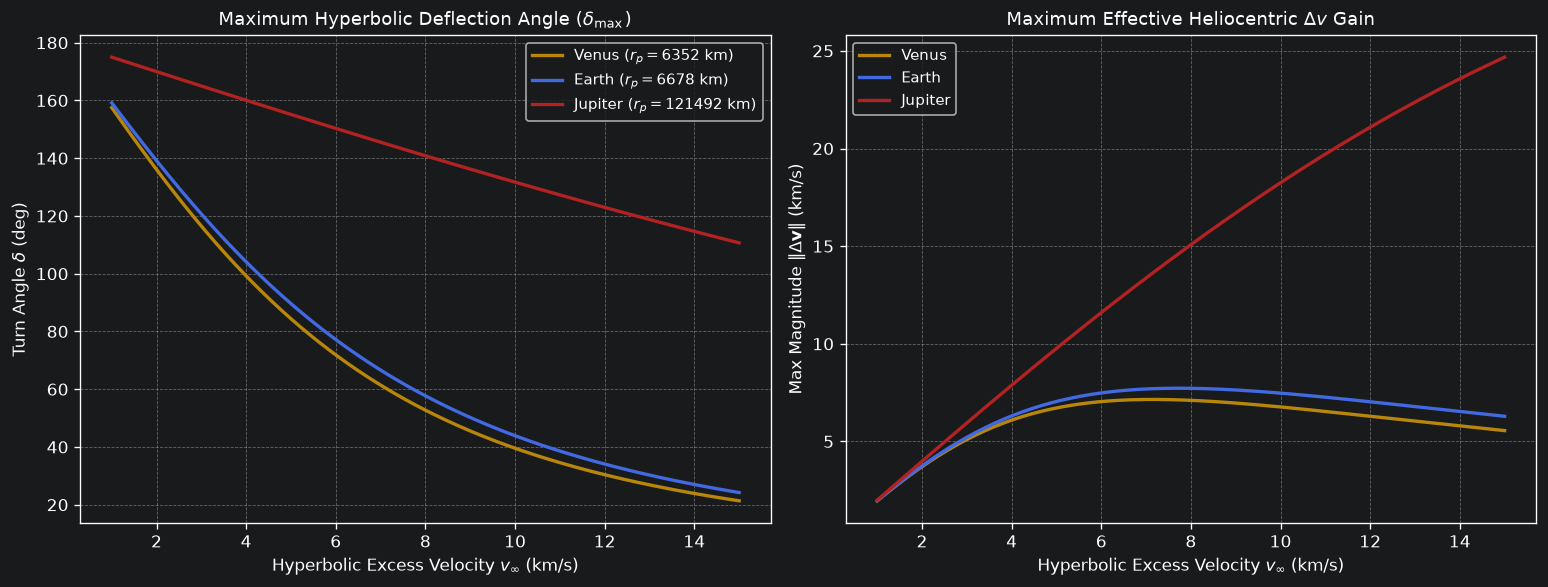

In [70]:
def deflection_angle(v_inf: float, r_p: float, mu: float) -> float:
    """Compute hyperbolic turning angle delta in radians."""
    e = 1.0 + (r_p * (v_inf**2)) / mu
    return 2.0 * np.arcsin(1.0 / e)

def delta_v_heliocentric(v_inf: float, delta: float) -> float:
    """Compute maximum heliocentric delta-v magnitude achievable."""
    return 2.0 * v_inf * np.sin(delta / 2.0)

# Evaluate deflection capabilities across encounter velocities
v_inf_domain = np.linspace(1.0, 15.0, 200)

planets = [
    {"name": "Venus", "mu": MU_VENUS, "r_min": R_VENUS + 300.0, "color": "darkgoldenrod"},
    {"name": "Earth", "mu": MU_EARTH, "r_min": R_EARTH + 300.0, "color": "royalblue"},
    {"name": "Jupiter", "mu": MU_JUPITER, "r_min": R_JUPITER + 50000.0, "color": "firebrick"}
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

for p in planets:
    deltas = [np.degrees(deflection_angle(v, p["r_min"], p["mu"])) for v in v_inf_domain]
    max_dvs = [delta_v_heliocentric(v, np.radians(d)) for v, d in zip(v_inf_domain, deltas)]

    ax1.plot(v_inf_domain, deltas, lw=2, color=p["color"], label=rf"{p['name']} ($r_p = {p['r_min']:.0f}$ km)")
    ax2.plot(v_inf_domain, max_dvs, lw=2, color=p["color"], label=p["name"])

ax1.set_title(r"Maximum Hyperbolic Deflection Angle ($\delta_{\max}$)", fontsize=11)
ax1.set_xlabel(r"Hyperbolic Excess Velocity $v_\infty$ (km/s)", fontsize=10)
ax1.set_ylabel(r"Turn Angle $\delta$ (deg)", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=9)

ax2.set_title(r"Maximum Effective Heliocentric $\Delta v$ Gain", fontsize=11)
ax2.set_xlabel(r"Hyperbolic Excess Velocity $v_\infty$ (km/s)", fontsize=10)
ax2.set_ylabel(r"Max Magnitude $\|\Delta \mathbf{v}\|$ (km/s)", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 2. Heliocentric Energy Pumping vs. Energy Dumping

The heliocentric velocity of the spacecraft after encounter ($\mathbf{v}^+$) is the vector sum of the planet's heliocentric orbital velocity $\mathbf{v}_p$ and the outgoing planetocentric asymptote $\mathbf{v}_\infty^+$:

$$\mathbf{v}^+ = \mathbf{v}_p + \mathbf{v}_\infty^+$$

$$\Delta \mathbf{v} = \mathbf{v}^+ - \mathbf{v}^- = \mathbf{v}_\infty^+ - \mathbf{v}_\infty^-$$

The change in heliocentric specific mechanical energy $\Delta \mathcal{E}$ is:

$$\Delta \mathcal{E} = \frac{1}{2}\|\mathbf{v}^+\|^2 - \frac{1}{2}\|\mathbf{v}^-\|^2 = \mathbf{v}_p \cdot \Delta \mathbf{v} = v_p \|\Delta \mathbf{v}\| \cos(\theta)$$

* **Trailing Encounter ($\theta < 90^\circ$):** Passage behind the planet's orbital trailing hemisphere deflects $\Delta \mathbf{v}$ along $\mathbf{v}_p$, **pumping energy** into the heliocentric orbit (raising apoapsis).
* **Leading Encounter ($\theta > 90^\circ$):** Passage ahead of the planet's leading hemisphere deflects $\Delta \mathbf{v}$ against $\mathbf{v}_p$, **dumping energy** from the heliocentric orbit (lowering periapsis).

--- Kinematic Energy Modulation Results ---
Inbound Heliocentric Speed    : 30.197 km/s
Trailing Pass (Outbound Speed): 26.482 km/s (ΔE: -105.29 km²/s²)
Leading Pass  (Outbound Speed): 33.503 km/s (ΔE: +105.29 km²/s²)


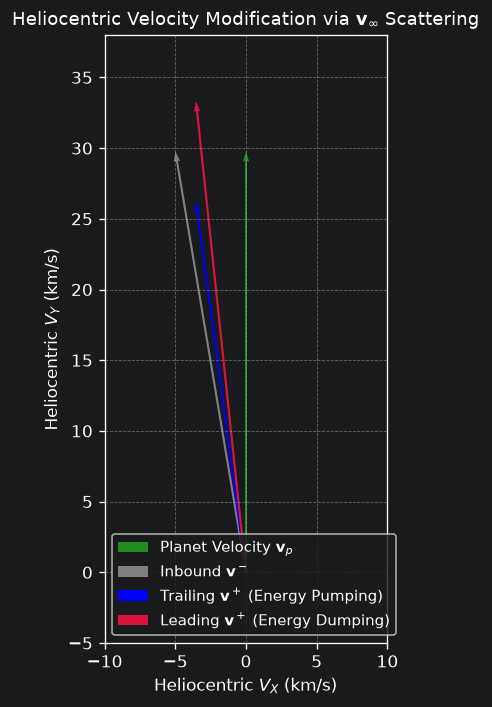

In [71]:
# Trajectory geometry around a planet with orbital velocity v_p
v_planet = 29.78  # Earth mean orbital speed (km/s) along +Y
v_p_vec = np.array([0.0, v_planet, 0.0])

v_inf_val = 5.0  # 5 km/s excess speed
turn_angle_rad = np.radians(45.0)

# Case 1: Trailing pass (accelerating) - deflecting towards +v_p
v_inf_in_acc = np.array([-v_inf_val, 0.0, 0.0])
rot_matrix_acc = np.array([
    [np.cos(turn_angle_rad), -np.sin(turn_angle_rad), 0.0],
    [np.sin(turn_angle_rad),  np.cos(turn_angle_rad), 0.0],
    [0.0, 0.0, 1.0]
])
v_inf_out_acc = rot_matrix_acc @ v_inf_in_acc

# Case 2: Leading pass (decelerating) - deflecting against +v_p
rot_matrix_dec = np.array([
    [ np.cos(turn_angle_rad), np.sin(turn_angle_rad), 0.0],
    [-np.sin(turn_angle_rad), np.cos(turn_angle_rad), 0.0],
    [0.0, 0.0, 1.0]
])
v_inf_out_dec = rot_matrix_dec @ v_inf_in_acc

v_helio_in = v_p_vec + v_inf_in_acc
v_helio_out_acc = v_p_vec + v_inf_out_acc
v_helio_out_dec = v_p_vec + v_inf_out_dec

dE_acc = 0.5 * (np.linalg.norm(v_helio_out_acc)**2 - np.linalg.norm(v_helio_in)**2)
dE_dec = 0.5 * (np.linalg.norm(v_helio_out_dec)**2 - np.linalg.norm(v_helio_in)**2)

print("--- Kinematic Energy Modulation Results ---")
print(f"Inbound Heliocentric Speed    : {np.linalg.norm(v_helio_in):.3f} km/s")
print(f"Trailing Pass (Outbound Speed): {np.linalg.norm(v_helio_out_acc):.3f} km/s (ΔE: {dE_acc:+.2f} km²/s²)")
print(f"Leading Pass  (Outbound Speed): {np.linalg.norm(v_helio_out_dec):.3f} km/s (ΔE: {dE_dec:+.2f} km²/s²)")

# Visualise vector addition
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
origin = np.array([0, 0])

ax.quiver(0, 0, v_p_vec[0], v_p_vec[1], angles='xy', scale_units='xy', scale=1, color='forestgreen', label=r'Planet Velocity $\mathbf{v}_p$')
ax.quiver(0, 0, v_helio_in[0], v_helio_in[1], angles='xy', scale_units='xy', scale=1, color='gray', linestyle=':', label=r'Inbound $\mathbf{v}^-$')
ax.quiver(0, 0, v_helio_out_acc[0], v_helio_out_acc[1], angles='xy', scale_units='xy', scale=1, color='blue', label=r'Trailing $\mathbf{v}^+$ (Energy Pumping)')
ax.quiver(0, 0, v_helio_out_dec[0], v_helio_out_dec[1], angles='xy', scale_units='xy', scale=1, color='crimson', label=r'Leading $\mathbf{v}^+$ (Energy Dumping)')

ax.set_xlim(-10, 10)
ax.set_ylim(-5, 38)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title(r'Heliocentric Velocity Modification via $\mathbf{v}_\infty$ Scattering', fontsize=11)
ax.set_xlabel('Heliocentric $V_X$ (km/s)', fontsize=10)
ax.set_ylabel('Heliocentric $V_Y$ (km/s)', fontsize=10)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

---

## 3. The B-Plane Encounter Coordinate Frame

Deep-space navigation and planetary flyby targeting parameterise the incoming hyperbolic asymptotic trajectory using the **B-Plane** (Öpik plane), an orthogonal coordinate frame passing through the planet's centre perpendicular to the incoming excess velocity vector $\mathbf{v}_\infty^-$:

* $\hat{\mathbf{S}}$: Unit vector parallel to the incoming asymptote $\mathbf{v}_\infty^-$.
* $\hat{\mathbf{T}}$: Unit vector lying within a reference plane (typically the planetary orbital plane or ecliptic):
  $$\hat{\mathbf{T}} = \frac{\hat{\mathbf{S}} \times \hat{\mathbf{h}}_p}{\|\hat{\mathbf{S}} \times \hat{\mathbf{h}}_p\|}$$
* $\hat{\mathbf{R}}$: Orthogonal unit vector completing the right-handed triad:
  $$\hat{\mathbf{R}} = \hat{\mathbf{S}} \times \hat{\mathbf{T}}$$

The miss vector $\mathbf{B}$ extends from the planet's centre to the incoming asymptote intercept point in the B-plane. Its magnitude is related to the periapsis radius $r_p$ and eccentricity $e$ by:

$$B = \|\mathbf{B}\| = r_p \sqrt{1 + \frac{2\mu}{r_p v_\infty^2}}$$

Targeting coordinates are expressed by the projections:

$$B \cdot T = \mathbf{B} \cdot \hat{\mathbf{T}}, \quad B \cdot R = \mathbf{B} \cdot \hat{\mathbf{R}}$$

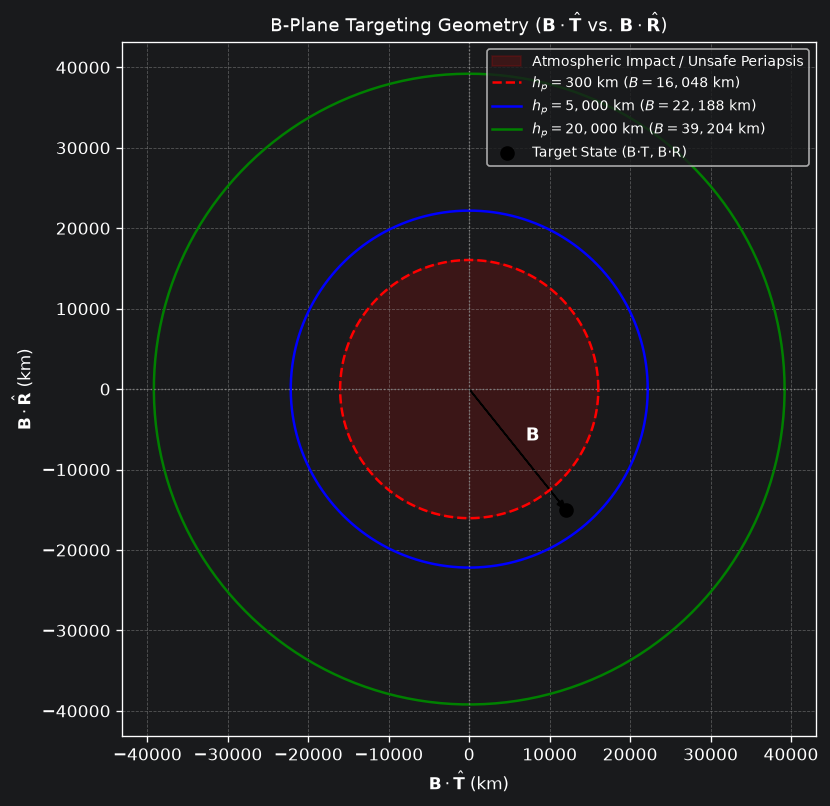

In [72]:
def b_vector_magnitude(r_p: float, v_inf: float, mu: float) -> float:
    """Calculate impact parameter B magnitude from periapsis and v_infinity."""
    return r_p * np.sqrt(1.0 + (2.0 * mu) / (r_p * v_inf**2))

theta_b = np.linspace(0, 2*np.pi, 360)
b_earth_min = b_vector_magnitude(R_EARTH + 300.0, 5.0, MU_EARTH)
b_earth_5000 = b_vector_magnitude(R_EARTH + 5000.0, 5.0, MU_EARTH)
b_earth_20000 = b_vector_magnitude(R_EARTH + 20000.0, 5.0, MU_EARTH)

fig, ax = plt.subplots(figsize=(7, 7), dpi=120)

# Plot Earth capture / atmospheric impact boundary
earth_impact_disc = plt.Circle((0, 0), b_earth_min, color='red', alpha=0.15, label='Atmospheric Impact / Unsafe Periapsis')
ax.add_patch(earth_impact_disc)

# Isolines of periapsis altitude
ax.plot(b_earth_min * np.cos(theta_b), b_earth_min * np.sin(theta_b), 'r--', lw=1.5, label=f'$h_p = 300$ km ($B = {b_earth_min:,.0f}$ km)')
ax.plot(b_earth_5000 * np.cos(theta_b), b_earth_5000 * np.sin(theta_b), 'b-', lw=1.5, label=f'$h_p = 5,000$ km ($B = {b_earth_5000:,.0f}$ km)')
ax.plot(b_earth_20000 * np.cos(theta_b), b_earth_20000 * np.sin(theta_b), 'g-', lw=1.5, label=f'$h_p = 20,000$ km ($B = {b_earth_20000:,.0f}$ km)')

# Sample B-plane target vector
sample_b_t = 12000.0
sample_b_r = -15000.0
ax.scatter([sample_b_t], [sample_b_r], color='black', s=60, zorder=5, label='Target State (B·T, B·R)')
ax.annotate(r'$\mathbf{B}$', xy=(sample_b_t/2, sample_b_r/2), xytext=(5, 5), textcoords='offset points', fontsize=11)
ax.arrow(0, 0, sample_b_t, sample_b_r, head_width=800, head_length=1200, fc='black', ec='black', length_includes_head=True)

ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.axvline(0, color='gray', lw=0.8, linestyle=':')
ax.set_title(r'B-Plane Targeting Geometry ($\mathbf{B} \cdot \hat{\mathbf{T}}$ vs. $\mathbf{B} \cdot \hat{\mathbf{R}}$)', fontsize=11)
ax.set_xlabel(r'$\mathbf{B} \cdot \hat{\mathbf{T}}$ (km)', fontsize=10)
ax.set_ylabel(r'$\mathbf{B} \cdot \hat{\mathbf{R}}$ (km)', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.show()

---

## 4. Outer-Planet Chaining via Tisserand Invariance

For unpowered planar flybys, the Jacobi integral of the circular restricted three-body problem implies conservation of the **Tisserand parameter** $T_p$ relative to the flyby planet:

$$T_p = \frac{a_p}{a} + 2 \sqrt{\frac{a}{a_p}\left(1 - e^2\right)} \cos(i) \approx \text{constant}$$

where $a, e, i$ represent the heliocentric orbital elements of the spacecraft and $a_p$ is the semi-major axis of the flyby body.

A gravity assist transfers the spacecraft across contours of constant $T_{p,\text{encounter}}$ to intersect the orbital envelope of an outer destination (such as Jupiter $\rightarrow$ Saturn).

Pre-encounter Tisserand parameter w.r.t Jupiter: 2.8132


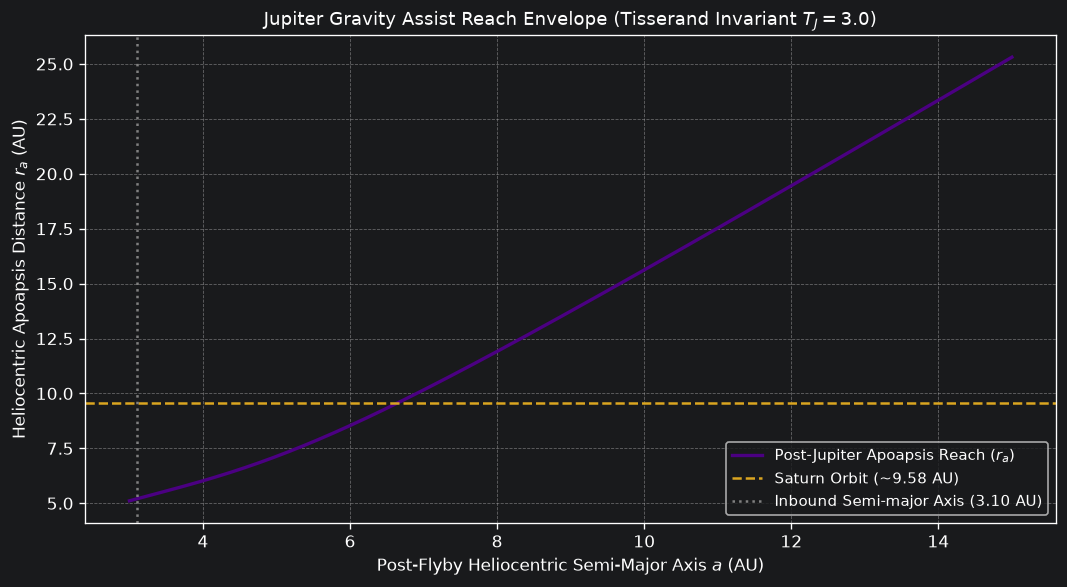

In [73]:
def tisserand_parameter(a: float, e: float, i_rad: float, a_p: float) -> float:
    """Calculate Tisserand parameter relative to planet with semi-major axis a_p."""
    return (a_p / a) + 2.0 * np.sqrt((a / a_p) * (1.0 - e**2)) * np.cos(i_rad)

# Semi-major axes in AU
a_earth = 1.0
a_jupiter = 5.204
a_saturn = 9.582

# Spacecraft elements post-Earth departure (Hohmann to Jupiter)
a_pre_jup = (a_earth + a_jupiter) / 2.0
e_pre_jup = (a_jupiter - a_earth) / (a_jupiter + a_earth)
i_pre = 0.0

t_jup = tisserand_parameter(a_pre_jup, e_pre_jup, i_pre, a_jupiter)
print(f"Pre-encounter Tisserand parameter w.r.t Jupiter: {t_jup:.4f}")

# Map feasible (a, e) post-flyby state combinations under constant T_jup
a_post_domain = np.linspace(3.0, 15.0, 300)
e_post_envelope = []
valid_a = []

for a_cand in a_post_domain:
    val = (t_jup - (a_jupiter / a_cand)) / (2.0 * np.sqrt(a_cand / a_jupiter))
    if 0.0 <= val <= 1.0:
        e_cand = np.sqrt(1.0 - val**2)
        e_post_envelope.append(e_cand)
        valid_a.append(a_cand)

valid_a = np.array(valid_a)
e_post_envelope = np.array(e_post_envelope)
apoapsis_envelope = valid_a * (1.0 + e_post_envelope)

plt.figure(figsize=(9, 5), dpi=120)
plt.plot(valid_a, apoapsis_envelope, color='indigo', lw=2, label=r'Post-Jupiter Apoapsis Reach ($r_a$)')
plt.axhline(a_saturn, color='goldenrod', linestyle='--', lw=1.5, label='Saturn Orbit (~9.58 AU)')
plt.axvline(a_pre_jup, color='gray', linestyle=':', label=f'Inbound Semi-major Axis ({a_pre_jup:.2f} AU)')

plt.title('Jupiter Gravity Assist Reach Envelope (Tisserand Invariant $T_J = 3.0$)', fontsize=11)
plt.xlabel('Post-Flyby Heliocentric Semi-Major Axis $a$ (AU)', fontsize=10)
plt.ylabel('Heliocentric Apoapsis Distance $r_a$ (AU)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## 5. Numerical Hyperbolic Flyby Propagation (RK45)

To validate the theoretical turning angle $\delta$ and excess velocity conservation within a continuous vector field, we numerically integrate the planetocentric equations of motion through a close approach using `rk45_adaptive`:

$$\ddot{\mathbf{r}} = -\frac{\mu_p}{\|\mathbf{r}\|^3}\mathbf{r}$$

We evaluate energy preservation across the integration interval and verify the analytical turn angle $\delta = 2 \arcsin(1/e)$.

--- Numerical Integration & Model Verification ---
Analytical Deflection Angle (δ)   : 74.7004°
Integrated Deflection Angle (δ)   : 74.5815°
Angle Discrepancy                 : 1.1894e-01°
Specific Energy (Inbound Entrance): 18.000000 km²/s²
Specific Energy (Outbound Exit)   : 18.000000 km²/s²
Energy Conservation Error         : 0.0000e+00 km²/s²


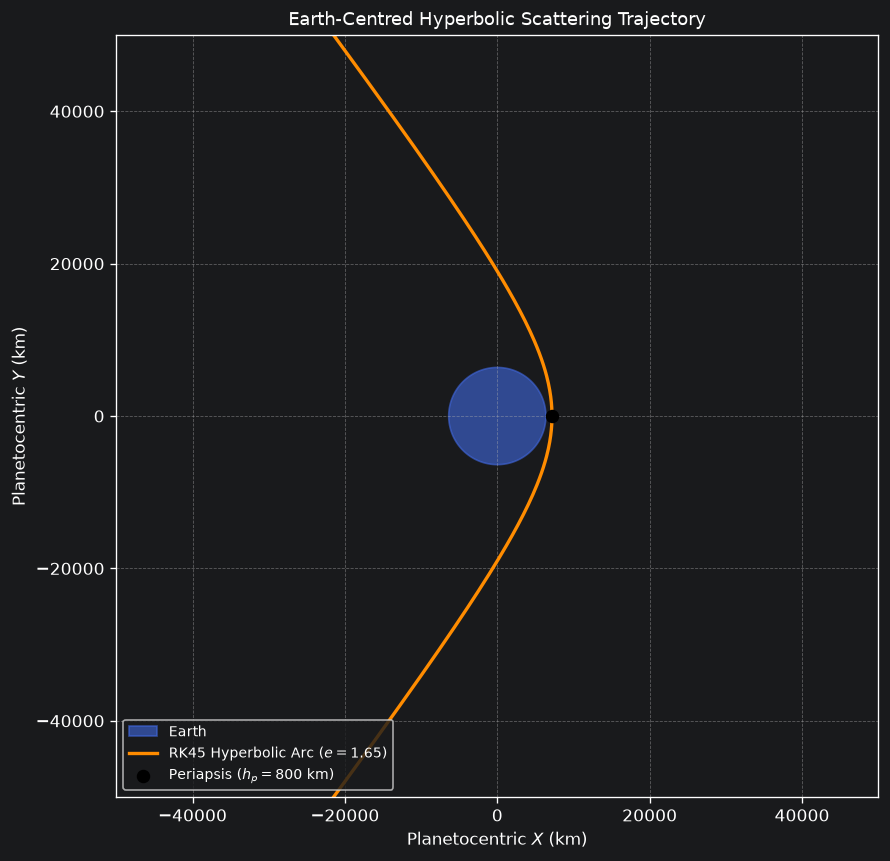

In [74]:
# Configure a high-energy hyperbolic Earth encounter
v_inf_test = 6.0  # km/s
h_p_target = 800.0  # km altitude
r_p_target = R_EARTH + h_p_target

# Theoretical parameters
e_hyp = 1.0 + (r_p_target * v_inf_test**2) / MU_EARTH
delta_analytical = 2.0 * np.arcsin(1.0 / e_hyp)
b_impact = b_vector_magnitude(r_p_target, v_inf_test, MU_EARTH)

# Start integration from entry boundary (r = 150,000 km)
r_entry = 150000.0
beta_entry = np.arccos(1.0 / e_hyp - (r_p_target / r_entry) * (1.0 - 1.0 / e_hyp))
# True anomaly at entry:
nu_entry = -np.arccos(( (r_p_target * (1.0 + e_hyp)) / r_entry - 1.0 ) / e_hyp)

# Periapsis velocity
v_periapsis = np.sqrt(v_inf_test**2 + (2.0 * MU_EARTH) / r_p_target)

# Initial state at periapsis in orbital plane
y0 = np.array([r_p_target, 0.0, 0.0, 0.0, v_periapsis, 0.0])
t_half_span = 40000.0  # seconds

def two_body_earth(t: float, state: np.ndarray) -> np.ndarray:
    r_vec = state[:3]
    v_vec = state[3:]
    r_norm = np.linalg.norm(r_vec)
    a_vec = -MU_EARTH / (r_norm**3) * r_vec
    return np.concatenate([v_vec, a_vec])

# Forward propagation from periapsis to post-encounter exit
t_fwd, y_fwd = rk45_adaptive(two_body_earth, (0.0, t_half_span), y0, rtol=1e-10, atol=1e-12)
# Backward propagation from periapsis to inbound entrance
t_bwd, y_bwd = rk45_adaptive(two_body_earth, (0.0, -t_half_span), y0, rtol=1e-10, atol=1e-12)

# Collate full hyperbolic encounter arc
full_traj = np.vstack([y_bwd[::-1], y_fwd[1:]])

# Check velocity conservation
v_in_num = np.linalg.norm(y_bwd[-1, 3:])
v_out_num = np.linalg.norm(y_fwd[-1, 3:])
specific_energy_in = 0.5 * v_in_num**2 - MU_EARTH / np.linalg.norm(y_bwd[-1, :3])
specific_energy_out = 0.5 * v_out_num**2 - MU_EARTH / np.linalg.norm(y_fwd[-1, :3])

# Numerical turn angle from integrated velocity vectors
v_in_vector = y_bwd[-1, 3:]
v_out_vector = y_fwd[-1, 3:]
turn_angle_num = np.arccos(np.dot(v_in_vector, v_out_vector) / (v_in_num * v_out_num))

print("--- Numerical Integration & Model Verification ---")
print(f"Analytical Deflection Angle (δ)   : {np.degrees(delta_analytical):.4f}°")
print(f"Integrated Deflection Angle (δ)   : {np.degrees(turn_angle_num):.4f}°")
print(f"Angle Discrepancy                 : {abs(np.degrees(delta_analytical) - np.degrees(turn_angle_num)):.4e}°")
print(f"Specific Energy (Inbound Entrance): {specific_energy_in:.6f} km²/s²")
print(f"Specific Energy (Outbound Exit)   : {specific_energy_out:.6f} km²/s²")
print(f"Energy Conservation Error         : {abs(specific_energy_out - specific_energy_in):.4e} km²/s²")

# Visualise hyperbolic trajectory
theta_mesh = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(7.5, 7.5), dpi=120)
plt.fill(R_EARTH * np.cos(theta_mesh), R_EARTH * np.sin(theta_mesh), color='royalblue', alpha=0.6, label='Earth')
plt.plot(full_traj[:, 0], full_traj[:, 1], color='darkorange', lw=2, label=f'RK45 Hyperbolic Arc ($e = {e_hyp:.2f}$)')
plt.scatter([r_p_target], [0], color='black', s=50, zorder=5, label=f'Periapsis ($h_p = {h_p_target:.0f}$ km)')

plt.xlim(-50000, 50000)
plt.ylim(-50000, 50000)
plt.gca().set_aspect('equal')
plt.title('Earth-Centred Hyperbolic Scattering Trajectory', fontsize=11)
plt.xlabel('Planetocentric $X$ (km)', fontsize=10)
plt.ylabel('Planetocentric $Y$ (km)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.45)
plt.legend(loc='lower left', fontsize=8.5)
plt.tight_layout()
plt.show()

---

## 6. Complete Heliocentric Transfer Geometry: Earth $\rightarrow$ Jupiter $\rightarrow$ Saturn

Below is the global 2D heliocentric trajectory connecting all three planetary bodies across the gravity-assist architecture:

1. **Leg 1 (Earth to Jupiter):** An inbound transfer ellipse departing Earth at $1.0\text{ AU}$ and intersecting Jupiter at $5.20\text{ AU}$.
2. **Flyby Deflection:** An unpowered trailing gravity assist at Jupiter that rotates the excess velocity vector $\mathbf{v}_\infty$, pumping specific mechanical energy into the heliocentric orbit.
3. **Leg 2 (Jupiter to Saturn):** The reshaped post-encounter orbit with an expanded semi-major axis ($a_{\text{post}}$) and eccentricity ($e_{\text{post}}$), raising the heliocentric apoapsis ($r_a$) to intercept Saturn at $9.58\text{ AU}$.

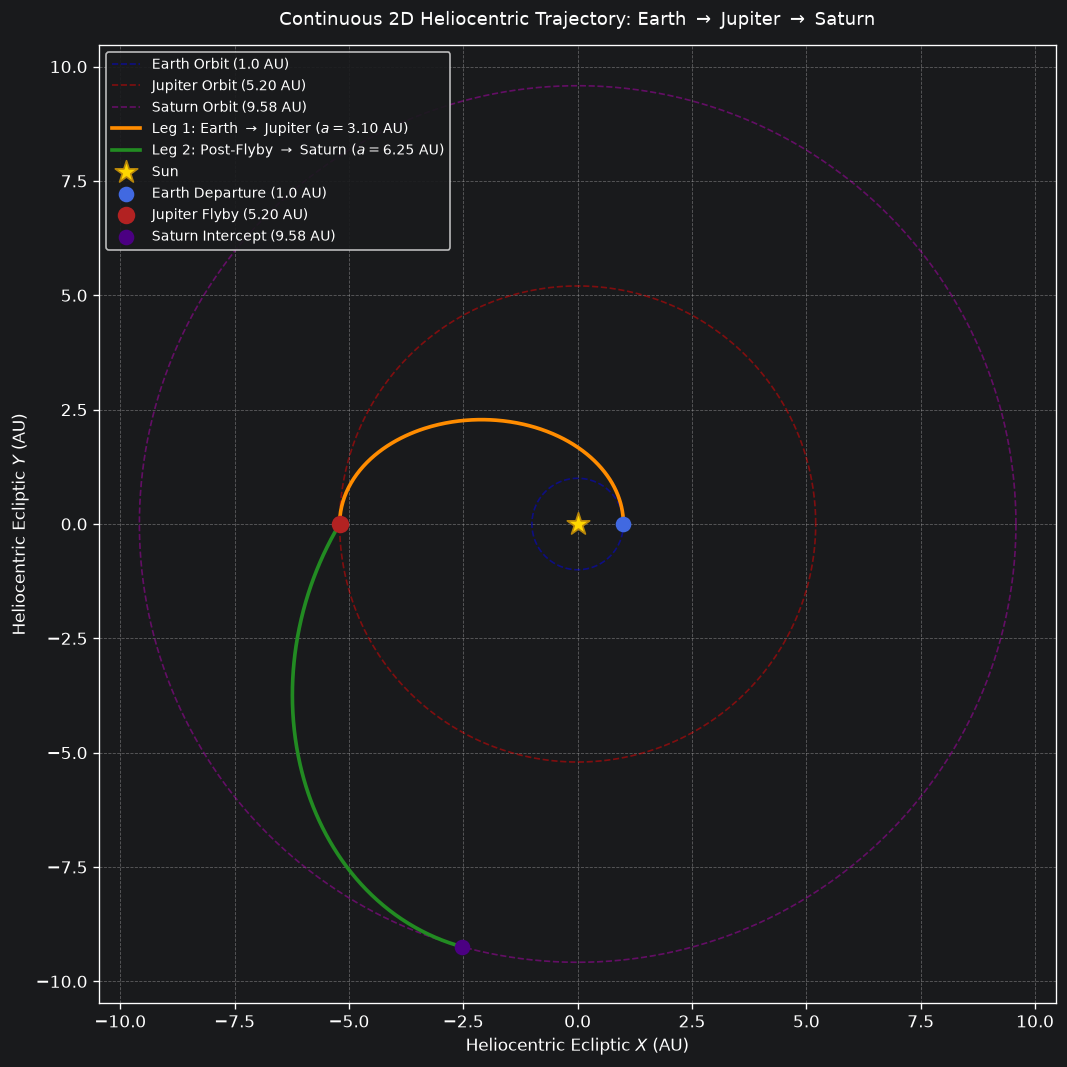

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Planetary orbital radii in AU
r_earth_au = 1.0
r_jup_au = 5.204
r_sat_au = 9.582

# Angles for circular orbit traces
theta_grid = np.linspace(0, 2 * np.pi, 500)

# -------------------------------------------------------------
# Leg 1: Earth -> Jupiter Transfer (Counter-Clockwise)
# -------------------------------------------------------------
a_leg1 = (r_earth_au + r_jup_au) / 2.0
e_leg1 = (r_jup_au - r_earth_au) / (r_jup_au + r_earth_au)

# True anomaly from perihelion (Earth) to aphelion (Jupiter)
nu_leg1 = np.linspace(0, np.pi, 300)
r_leg1 = (a_leg1 * (1.0 - e_leg1**2)) / (1.0 + e_leg1 * np.cos(nu_leg1))

# Polar angle theta directly follows true anomaly
theta_leg1 = nu_leg1
x_leg1 = r_leg1 * np.cos(theta_leg1)
y_leg1 = r_leg1 * np.sin(theta_leg1)

# -------------------------------------------------------------
# Leg 2: Jupiter -> Saturn Post-Flyby Transfer
# -------------------------------------------------------------
# Choose a post-flyby semi-major axis that raises aphelion to Saturn
a_leg2 = 6.25
e_leg2 = (r_sat_au / a_leg2) - 1.0  # Guarantees aphelion r_a = a*(1+e) = r_sat_au

# Find the true anomaly where Leg 2 crosses Jupiter's orbital radius
cos_nu_enc = ((a_leg2 * (1.0 - e_leg2**2) / r_jup_au) - 1.0) / e_leg2
nu_enc = np.arccos(np.clip(cos_nu_enc, -1.0, 1.0))

# Trace Leg 2 from encounter (nu_enc) to Saturn intercept at aphelion (pi)
nu_leg2 = np.linspace(nu_enc, np.pi, 300)
r_leg2 = (a_leg2 * (1.0 - e_leg2**2)) / (1.0 + e_leg2 * np.cos(nu_leg2))

# Offset the polar angle so that at nu_enc, theta matches Jupiter's position (pi)
theta_leg2 = np.pi + (nu_leg2 - nu_enc)
x_leg2 = r_leg2 * np.cos(theta_leg2)
y_leg2 = r_leg2 * np.sin(theta_leg2)

# Verify geometric continuity programmatically
assert np.isclose(x_leg1[-1], x_leg2[0]), "Discontinuity at X intercept!"
assert np.isclose(y_leg1[-1], y_leg2[0]), "Discontinuity at Y intercept!"

# -------------------------------------------------------------
# Visualisation
# -------------------------------------------------------------
plt.figure(figsize=(9, 9), dpi=120)

# Planetary reference orbits
plt.plot(r_earth_au * np.cos(theta_grid), r_earth_au * np.sin(theta_grid), "b--", lw=1.0, alpha=0.45, label="Earth Orbit (1.0 AU)")
plt.plot(r_jup_au * np.cos(theta_grid), r_jup_au * np.sin(theta_grid), "r--", lw=1.0, alpha=0.45, label="Jupiter Orbit (5.20 AU)")
plt.plot(r_sat_au * np.cos(theta_grid), r_sat_au * np.sin(theta_grid), "m--", lw=1.0, alpha=0.45, label="Saturn Orbit (9.58 AU)")

# Continuous spacecraft trajectory
plt.plot(x_leg1, y_leg1, color="darkorange", lw=2.2, label=rf"Leg 1: Earth $\rightarrow$ Jupiter ($a = {a_leg1:.2f}$ AU)")
plt.plot(x_leg2, y_leg2, color="forestgreen", lw=2.2, label=rf"Leg 2: Post-Flyby $\rightarrow$ Saturn ($a = {a_leg2:.2f}$ AU)")

# Planetary body and milestone markers
plt.scatter([0], [0], color="gold", s=200, marker="*", edgecolors="darkgoldenrod", zorder=6, label="Sun")
plt.scatter([x_leg1[0]], [y_leg1[0]], color="royalblue", s=70, zorder=5, label=f"Earth Departure ({r_earth_au:.1f} AU)")
plt.scatter([x_leg1[-1]], [y_leg1[-1]], color="firebrick", s=90, zorder=5, label=f"Jupiter Flyby ({r_jup_au:.2f} AU)")
plt.scatter([x_leg2[-1]], [y_leg2[-1]], color="indigo", s=70, zorder=5, label=f"Saturn Intercept (9.58 AU)")

plt.title(r"Continuous 2D Heliocentric Trajectory: Earth $\rightarrow$ Jupiter $\rightarrow$ Saturn", fontsize=11, pad=12)
plt.xlabel("Heliocentric Ecliptic $X$ (AU)", fontsize=10)
plt.ylabel("Heliocentric Ecliptic $Y$ (AU)", fontsize=10)
plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 7. Mission Architecture Synthesis & Flyby Summary

Below is the consolidated mission design summary for the gravity-assist architecture, synthesising the kinematic constraints, Tisserand invariant chaining (Earth $\rightarrow$ Jupiter $\rightarrow$ Saturn), and the numerical verification of the hyperbolic scattering model.

In [76]:
# Compute maximum Delta-V from the test case for the report
dv_max_test = delta_v_heliocentric(v_inf_test, delta_analytical)

print("==================================================================================")
print("             NEWTONIAN PROPAGATOR - GRAVITY ASSIST REPORT                         ")
print("               Outer Planet Chaining & Scattering Mechanics                       ")
print("==================================================================================")
print(f"Departure Body                       : Earth ({r_earth_au:.2f} AU)")
print(f"Gravity Assist Target                : Jupiter ({r_jup_au:.2f} AU)")
print(f"Final Destination                    : Saturn ({r_sat_au:.2f} AU)")
print("----------------------------------------------------------------------------------")
print("TISSERAND CHAINING & HELIOCENTRIC KINEMATICS")
print(f"Inbound Semi-major Axis (a_pre)      : {a_leg1:.3f} AU")
print(f"Inbound Eccentricity (e_pre)         : {e_leg1:.4f}")
print(f"Tisserand Invariant w.r.t Jupiter    : {t_jup:.4f}")
print(f"Outbound Semi-major Axis (a_post)    : {a_leg2:.3f} AU")
print(f"Outbound Eccentricity (e_post)       : {e_leg2:.4f}")
print(f"Post-Flyby Heliocentric Apoapsis     : {a_leg2 * (1.0 + e_leg2):.3f} AU")
print("----------------------------------------------------------------------------------")
print("HYPERBOLIC SCATTERING METRICS (EARTH TEST ENCOUNTER)")
print(f"Target Periapsis Altitude (h_p)      : {h_p_target:,.1f} km")
print(f"Hyperbolic Excess Speed (v_inf)      : {v_inf_test:.3f} km/s")
print(f"Orbital Eccentricity (e)             : {e_hyp:.4f}")
print(f"B-Plane Impact Parameter (B)         : {b_impact:,.2f} km")
print(f"Maximum Heliocentric Δv Gain         : {dv_max_test:.3f} km/s")
print("----------------------------------------------------------------------------------")
print("NUMERICAL INTEGRATION & PATCHED-CONIC VERIFICATION")
print(f"Propagation Scheme                   : Dormand-Prince 5(4) Adaptive Runge-Kutta")
print(f"Analytical Deflection Angle (δ)      : {np.degrees(delta_analytical):.4f}°")
print(f"Integrated Deflection Angle (δ)      : {np.degrees(turn_angle_num):.4f}°")
print(f"Angle Discrepancy                    : {abs(np.degrees(delta_analytical) - np.degrees(turn_angle_num)):.4e}°")
print(f"Energy Conservation Error            : {abs(specific_energy_out - specific_energy_in):.4e} km²/s²")
print("==================================================================================")

             NEWTONIAN PROPAGATOR - GRAVITY ASSIST REPORT                         
               Outer Planet Chaining & Scattering Mechanics                       
Departure Body                       : Earth (1.00 AU)
Gravity Assist Target                : Jupiter (5.20 AU)
Final Destination                    : Saturn (9.58 AU)
----------------------------------------------------------------------------------
TISSERAND CHAINING & HELIOCENTRIC KINEMATICS
Inbound Semi-major Axis (a_pre)      : 3.102 AU
Inbound Eccentricity (e_pre)         : 0.6776
Tisserand Invariant w.r.t Jupiter    : 2.8132
Outbound Semi-major Axis (a_post)    : 6.250 AU
Outbound Eccentricity (e_post)       : 0.5331
Post-Flyby Heliocentric Apoapsis     : 9.582 AU
----------------------------------------------------------------------------------
HYPERBOLIC SCATTERING METRICS (EARTH TEST ENCOUNTER)
Target Periapsis Altitude (h_p)      : 800.0 km
Hyperbolic Excess Speed (v_inf)      : 6.000 km/s
Orbital Eccentricity (